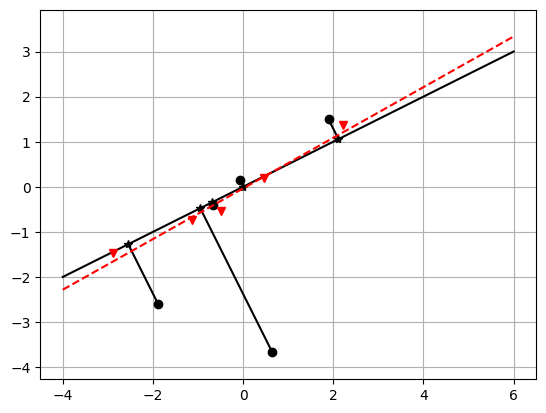

In [7]:
import numpy as np
import numpy.linalg as alg
import matplotlib.pyplot as plt

# Partie A
plt.figure(1)

n = 5    # nombre de points
x = -3 + 8 * np.random.rand(n)  # abscisses (utiliser numpy.random.rand)
y = -4 + 7 * np.random.rand(n)  # ordonnées (utiliser numpy.random.rand)
plt.plot(x, y, 'ok')  # affichage des points (cercles noirs)
U = np.vstack((x, y))  # matrice 2xn (concaténation verticale des vecteurs x et y), chaque colonne de U est un point Pi

# droite d'équation z(t)=0.5*t
t = np.array([-4, 6])  # abscisses
z = t / 2              # ordonnées
plt.plot(t, z, 'k')    # affichage de la droite (trait continu)

# propriétés du repère
plt.axis([-3, 5, -4, 3])
plt.grid(True)
plt.axis('equal')

# vecteur directeur unitaire de la droite
N = np.array([[2], [1]]) / alg.norm(np.array([[2], [1]]))

# matrice de projections sur la droite
P = N @ N.T

# d'abord initialisation d'une matrice 2xn pour les points de projection (utiliser numpy.zeros)
V = np.zeros((2, n))
# puis calcul des coordonnées des points projetés [chaque colonne de V est un point Qi]
for k in range(n):
    V[:, k] = P @ U[:, k]   # (k+1)ème colonne de V

# affichage des points projetés (étoiles noires)
plt.plot(V[0, :], V[1, :],'*k')

# on relie les points initiaux à leurs projections
for k in range(n):
    plt.plot([U[0, k], V[0, k]], [U[1, k], V[1, k]],'k')

# on perturbe les coordonnées des points projetés
delta = 0.5
dV = -delta + 2 * delta * np.random.rand(2, n)
W = V + dV

# affichage des points perturbés (triangles noirs)
plt.plot(W[0, :], W[1, :], 'vr')

# calcul de la droite passant au plus près des points perturbés
A = np.vstack((W[0, :],np.ones(n))).T
v = W[1, :].reshape(-1, 1)
u = alg.inv(A.T @ A) @ (A.T @ v)

# affichage de la droite (en pointillés)
plt.plot(t, u[0, 0] * t + u[1, 0], 'r--')



--- Astéroïde 1 ---
Coefficients: a=-0.039, b=-0.063, c=0.020, d=-0.035, e=0.543
Distance ||Au - v|| : 0.00043



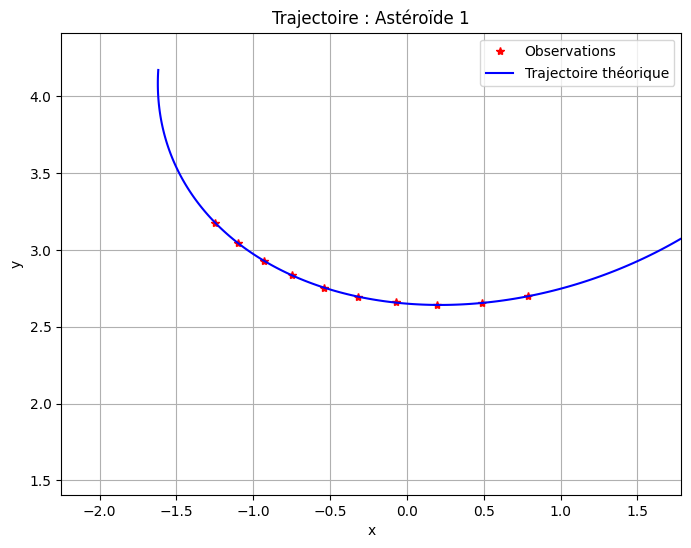

--- Astéroïde 2 ---
Coefficients: a=0.069, b=-0.445, c=0.038, d=-0.166, e=1.382
Distance ||Au - v|| : 0.04463



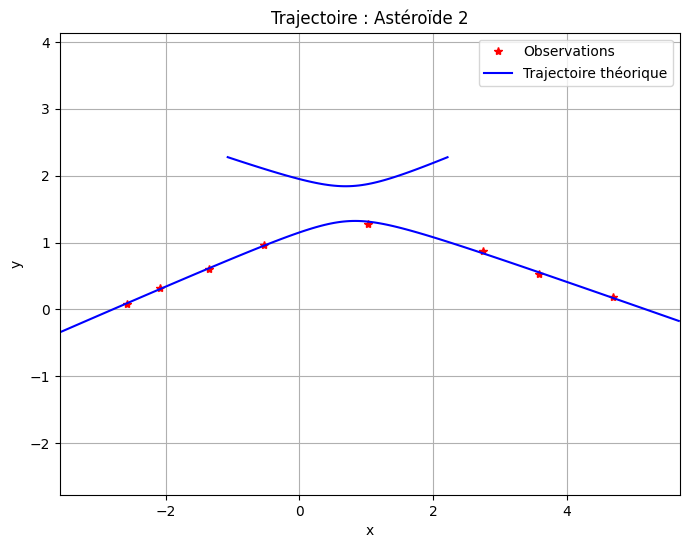

In [8]:
# Cellule pour Partie B (Fichier tp_ex2b.ipynb)

def resoudre_trajectoire(x_data, y_data, nom_asteroide="Astéroïde"):
    """
    Résout le problème de trajectoire conique Au=v et affiche le résultat.
    Modèle: a*x^2 + b*y^2 + c*xy + d*x + e*y = 1 (f fixe à -1 déplacé à droite)
    """
    n = len(x_data)
    
    # 1. Construction du système Au = v
    # A = [x^2  y^2  xy  x  y]
    A = np.zeros((n, 5))
    A[:, 0] = x_data**2
    A[:, 1] = y_data**2
    A[:, 2] = x_data * y_data
    A[:, 3] = x_data
    A[:, 4] = y_data
    
    # v est un vecteur colonne de 1
    v = np.ones((n, 1))
    
    # 2. Résolution aux moindres carrés via équations normales
    # u = (A.T A)^-1 A.T v
    Gram = A.T @ A
    u = alg.inv(Gram) @ (A.T @ v)
    
    # Extraction des coefficients
    a, b, c, d, e = u.flatten()
    f = -1.0 # Correspond au v=1 passé de l'autre côté
    
    # 3. Calcul de la distance (erreur résiduelle) ||Au - v||
    erreur = alg.norm(A @ u - v)
    print(f"--- {nom_asteroide} ---")
    print(f"Coefficients: a={a:.3f}, b={b:.3f}, c={c:.3f}, d={d:.3f}, e={e:.3f}")
    print(f"Distance ||Au - v|| : {erreur:.5f}\n")
    
    # 4. Affichage
    plt.figure(figsize=(8, 6))
    
    # Points d'observation
    plt.plot(x_data, y_data, 'r*', label='Observations')
    
    # Tracé de la conique (méthode de la grille et contour)
    x_min, x_max = np.min(x_data), np.max(x_data)
    y_min, y_max = np.min(y_data), np.max(y_data)
    margin = 1.0
    
    xv = np.linspace(x_min - margin, x_max + margin, 200)
    yv = np.linspace(y_min - margin, y_max + margin, 200)
    X, Y = np.meshgrid(xv, yv)
    
    # Equation implicite F(x,y) = 0
    Z = a*X**2 + b*Y**2 + c*X*Y + d*X + e*Y + f
    
    plt.contour(X, Y, Z, levels=[0], colors='blue')
    # Astuce pour la légende du contour
    plt.plot([], [], 'b-', label='Trajectoire théorique')
    
    plt.title(f"Trajectoire : {nom_asteroide}")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.legend()
    plt.axis('equal')
    plt.show()

# --- Données Astéroïde 1 ---
x1 = np.array([-1.25, -1.10, -0.932, -0.746, -0.542, -0.320, -0.074, 0.194, 0.490, 0.786])
y1 = np.array([3.178, 3.046, 2.930, 2.834, 2.754, 2.696, 2.658, 2.642, 2.654, 2.698])

# --- Données Astéroïde 2 ---
x2 = np.array([-2.5815, -2.0762, -1.3565, -0.5279, 1.0265, 2.7484, 3.5944, 4.6929])
y2 = np.array([0.0847, 0.3172, 0.6058, 0.9590, 1.2828, 0.8756, 0.5226, 0.1792])

# Exécution
resoudre_trajectoire(x1, y1, "Astéroïde 1")
resoudre_trajectoire(x2, y2, "Astéroïde 2")